In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
reviews_df = pd.read_csv(r"C:\Users\REYA\Downloads\apps.csv")
df

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9651,10833,Chemin (fr),BOOKS_AND_REFERENCE,4.8,44,0.6,1000,Free,0.0,Everyone,Books & Reference,"March 23, 2014",0.8,2.2 and up
9652,10834,FR Calculator,FAMILY,4.0,7,2.6,500,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
9654,10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
9655,10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,"July 6, 2018",1,4.1 and up


In [81]:
df.columns

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')

In [82]:
# Clean Installs column
df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Size column
df['Size'] = df['Size'].astype(str).str.replace('M', '', regex=False)
df['Size'] = df['Size'].astype(str).str.replace('k', '', regex=False)
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

# Clean Price column
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

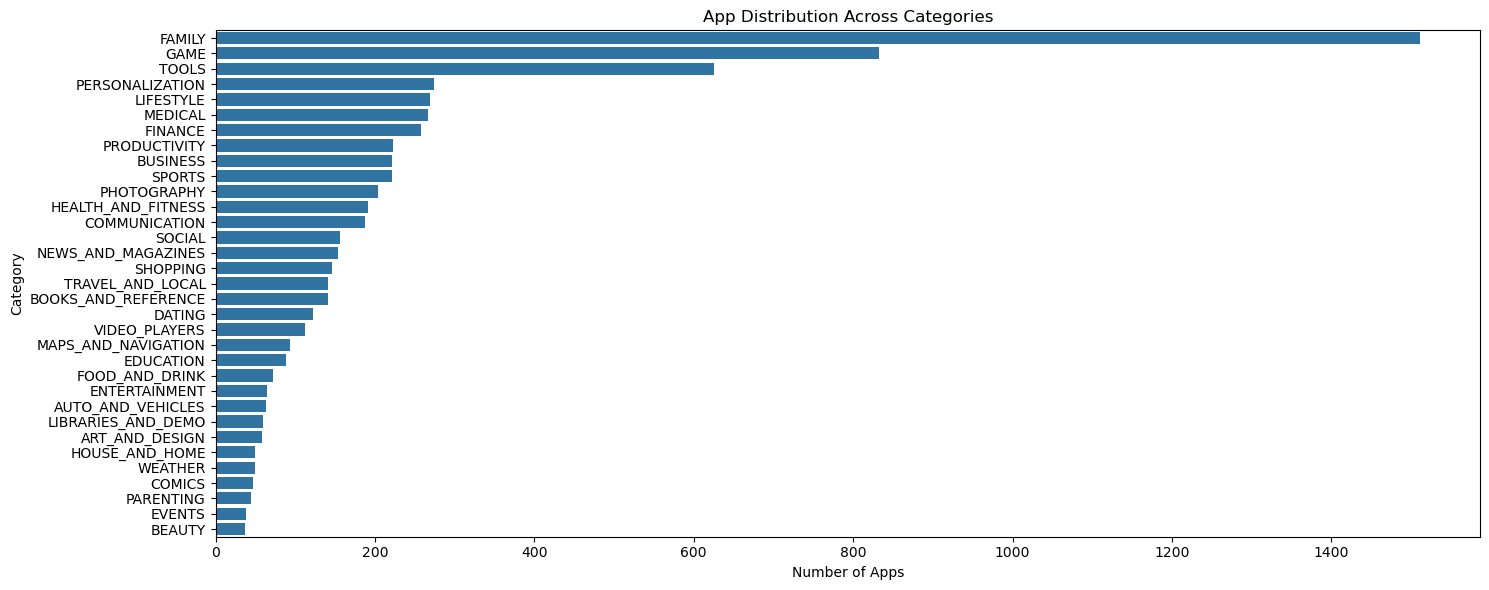

In [83]:
# App distribution across categories
plt.figure(figsize=(15, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title("App Distribution Across Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

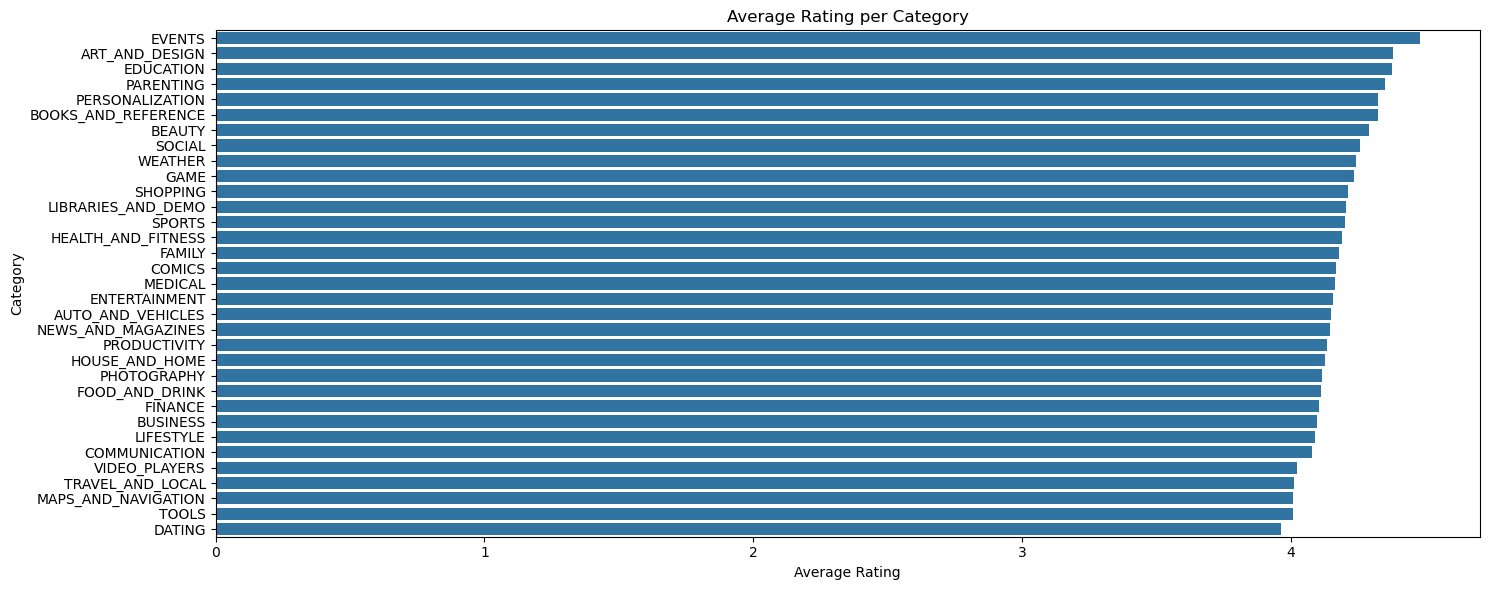

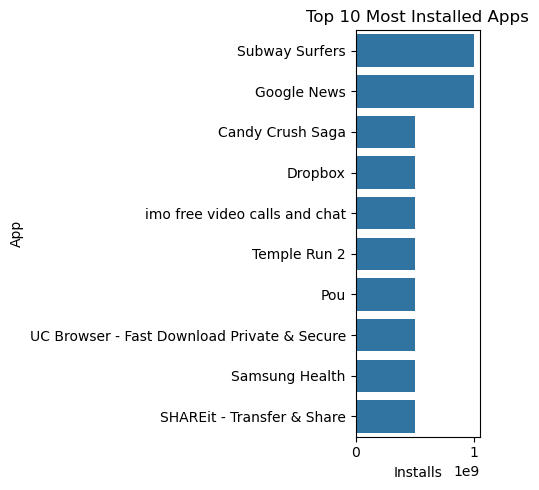

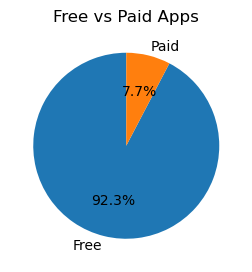

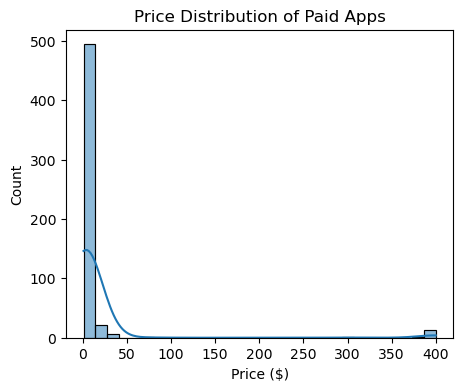

In [84]:
# Average Rating per Category
plt.figure(figsize=(15, 6))
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title("Average Rating per Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Top 10 Most Installed Apps
plt.figure(figsize=(5, 5))
top_installs = df[['App', 'Installs']].sort_values(
    by='Installs', ascending=False).head(10)
sns.barplot(x='Installs', y='App', data=top_installs)
plt.title("Top 10 Most Installed Apps")
plt.tight_layout()
plt.show()

# Free vs Paid Apps
plt.figure(figsize=(3, 4))
df['Type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("Free vs Paid Apps")
plt.ylabel("")
plt.show()

# Price Distribution of Paid Apps
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(5, 4))
sns.histplot(paid_apps['Price'], bins=30, kde=True)
plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.show()

                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   
3  10 Best Foods for You         Works great especially going grocery store   
4  10 Best Foods for You                                       Best idea us   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  
3  Positive                0.40                0.875000  
4  Positive                1.00                0.300000  
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


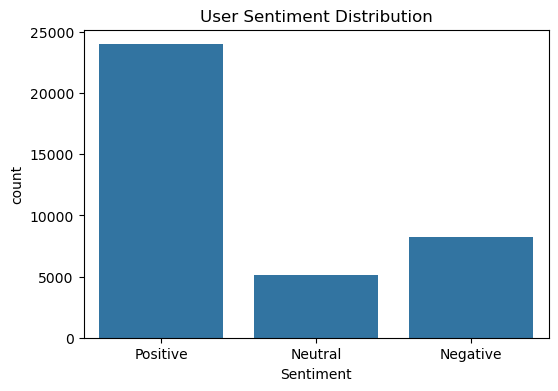

In [85]:
from textblob import TextBlob

# Load reviews dataset
reviews_df = pd.read_csv("user_reviews.csv")
print(reviews_df.head())
print(reviews_df.isnull().sum())

# Drop missing
reviews_df = reviews_df.dropna(subset=['Translated_Review'])

# Get sentiment polarity
def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

reviews_df['Sentiment'] = reviews_df['Translated_Review'].apply(get_sentiment)

# Plot sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Sentiment', data=reviews_df)
plt.title("User Sentiment Distribution")
plt.show()

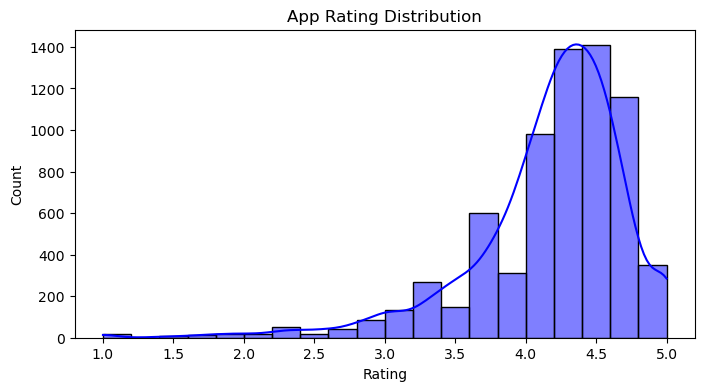

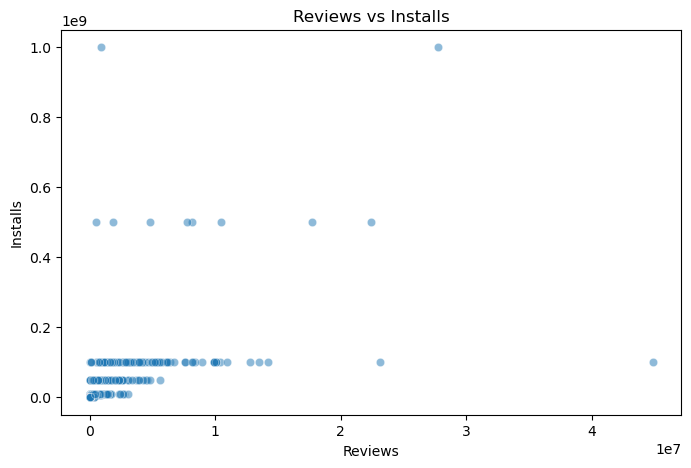

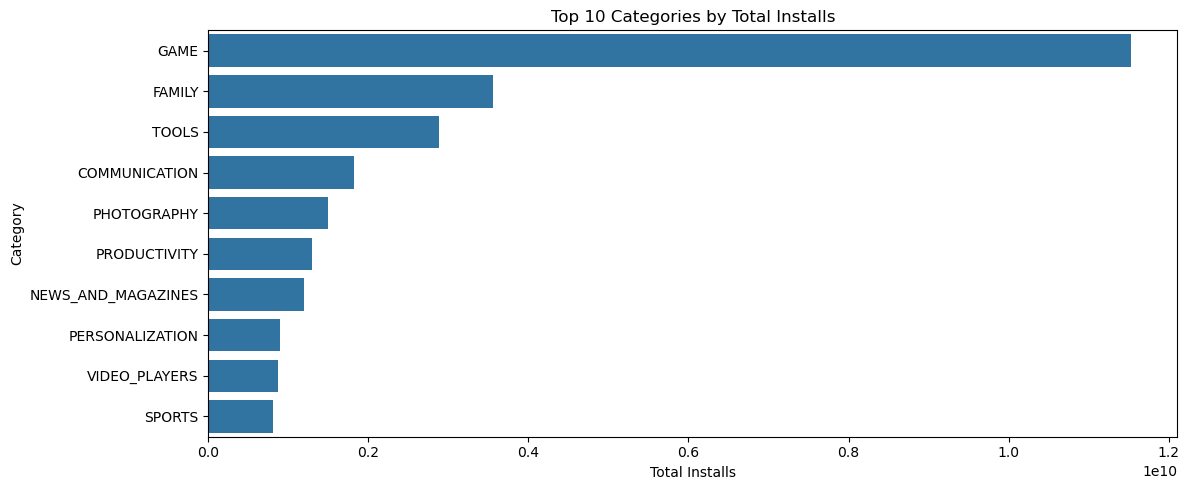

In [96]:
# Rating Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Rating'], bins=20, kde=True, color='blue')
plt.title("App Rating Distribution")
plt.xlabel("Rating")
plt.show()

# Reviews vs Installs
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Reviews', y='Installs', data=df, alpha=0.5)
plt.title("Reviews vs Installs")
plt.xlabel("Reviews")
plt.ylabel("Installs")
plt.show()

# Top 10 Categories by Installs
plt.figure(figsize=(12, 5))
top_cat = df.groupby('Category')['Installs'].sum().sort_values(
    ascending=False).head(10)
sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Total Installs")
plt.tight_layout()
plt.show()